# Start-to-Finish Cartesian Wave Project

Generate, build, run, and inspect the standalone Cartesian wave project from start to finish.

Navigation: [Index](../index.ipynb) |
Previous: [Wave Equation and C Code Generation](wave_equation_and_c_codegen.ipynb) |
Next: [Reference-Metric Applications][reference-metric-applications]

[reference-metric-applications]: ../4-curvilinear/reference_metric_applications.ipynb

## Learning Goals

- Generate a complete standalone Cartesian wave project.
- Identify the parameter file, build file, RHS source, executable, and diagnostics.
- Run two resolutions and compare sampled relative diagnostic errors.

## Words for This Notebook

- **Project:** a folder containing all files needed to build and run one generated program.
- **Parameter file:** a text file of run settings read by the executable.
- **Executable:** the compiled program you can run.
- **Diagnostic:** output used to judge whether the run behaved correctly.
- **Right-hand-side (RHS) source:** the C file containing formulas for time changes.
- **Function declaration:** a C line that names a function and its inputs.
- **Convergence factor:** the resolution multiplier passed to the executable.
- **BHaH:** the NRPy code-writing infrastructure used by this generator.
- **Method of Lines (MoL):** the time-stepping structure used by the generated code.

Use the code cells actively: first predict what should happen, then run the cell,
then explain the output in plain language.

## Table of Contents

- [Project Workflow Map](#project-workflow-map)
- [Generate Project](#generate-project)
- [Generated File Catalog](#generated-file-catalog)
- [Inspect Files](#inspect-files)
- [Run Diagnostics](#run-diagnostics)
- [Validate Cartesian Diagnostics](#validate-cartesian-diagnostics)
- [Plot Cartesian Diagnostics](#plot-cartesian-diagnostics)

## Project Workflow Map

The generator turns the first-order wave system into a runnable C project. The
main flow is:

| Stage | Generated artifact | What it contributes |
| --- | --- | --- |
| Exact wave solution | `initial_data` and diagnostic code | trusted values for setup and checks |
| Symbolic right-hand sides | `rhs_eval.c` | updates `u` and `v` on the grid |
| Time stepping | `MoL/` sources | RK4 stages that call the RHS update |
| Boundary handling | `apply_bcs.c` | fills ghost zones outside the Cartesian grid |
| Runtime diagnostics | `diagnostics.c` and `out0d-*.txt` | sampled numerical-vs-exact errors |

## Generate Project

The command creates the generated project described in the workflow map. The
first useful evidence is the project directory and the file inventory.

## Import Cartesian Project Execution Helpers

These standard-library tools run commands, manage temporary project directories,
and clean command output.

If you are new to Python, skim this helper cell on a first pass. Its job is to
run terminal commands, shorten long command output, and stop clearly if a
required tool is missing.

In [1]:
from pathlib import Path
import math
import re
import shutil
import subprocess
import sys
import tempfile


def clean_command_output(text):
    cleaned = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", text or "")
    return cleaned.replace(str(WORKSPACE), "<workspace>")


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=True,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    except subprocess.CalledProcessError as exc:
        print(clean_command_output(exc.stdout))
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}") from exc
    return clean_command_output(result.stdout)


def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError(
            "This notebook requires make to build the generated project."
        )
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError(
            "This notebook requires a C compiler such as cc, gcc, or clang."
        )


def replace_once(text, old, new, label):
    count = text.count(old)
    if count != 1:
        raise RuntimeError(
            f"Expected exactly one {label} setting to replace; found {count}."
        )
    print("updated runtime setting:", label)
    return text.replace(old, new, 1)

## Step 1: Create a Cartesian Project Workspace

The workspace keeps generated files separate from the tutorial source tree.

In [2]:
PROJECT_NAME = "wave_equation_cartesian"
workspace_manager = tempfile.TemporaryDirectory(
    prefix="nrpy_tutorial_cartesian_", dir=Path.cwd()
)
WORKSPACE = Path(workspace_manager.name)
PROJECT_DIR = WORKSPACE / "project" / PROJECT_NAME
print("workspace:", WORKSPACE)
print("project path:", PROJECT_DIR)

workspace: /work/3-wave_equation/nrpy_tutorial_cartesian_tep8iw67
project path: /work/3-wave_equation/nrpy_tutorial_cartesian_tep8iw67/project/wave_equation_cartesian


## Step 2: Generate the Cartesian Wave Project

This command invokes the same module a learner can run from a terminal and then
verifies that the project directory exists.

In [3]:
command = [sys.executable, "-m", "nrpy.examples.wave_equation_cartesian"]
print("generator command: python -m nrpy.examples.wave_equation_cartesian")
output = run_command(command, WORKSPACE, timeout=300)
for line in output.splitlines():
    if line.strip():
        print(line.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
print("generated project:", PROJECT_DIR.relative_to(WORKSPACE))

generator command: python -m nrpy.examples.wave_equation_cartesian


Finished! Now go into project/wave_equation_cartesian and type `make` to build, then ./wave_equation_cartesian to run.
    Parameter file can be found in wave_equation_cartesian.par
generated project: project/wave_equation_cartesian


## Generated File Catalog

| Name | Purpose | What to Inspect |
| --- | --- | --- |
| `wave_equation_cartesian.par` | runtime settings | `wavespeed`, `t_final`, output cadence |
| `Makefile` | build rules | compiler flags and source list |
| `rhs_eval.c` | wave update formula | grid loop, finite differences, RHS writes |
| `MoL/` | RK4 time stepping | calls into `rhs_eval.c` |
| `apply_bcs.c` | Cartesian boundary fill | ghost-zone updates |
| `diagnostics.c` | sampled error output | numerical and exact values at the grid center |
| `out0d-conv_factor*.txt` | diagnostics | relative errors and sampled `u` values |

## Inspect Files

The next cells confirm and read the generated files from the catalog.

## Step 3: Confirm the Generated Project Directory

Only after generation do we name the generated project files. The inventory is
intentionally compact.

In [4]:
required = [
    "Makefile",
    "BHaH_function_prototypes.h",
    "rhs_eval.c",
    "wave_equation_cartesian.par",
]
for relative_path in required:
    path = PROJECT_DIR / relative_path
    if not path.is_file():
        raise FileNotFoundError(path)
print("selected generated files:")
for relative_path in required:
    print(relative_path)
for subdir in ["MoL", "diagnostics"]:
    count = (
        sum(1 for path in (PROJECT_DIR / subdir).glob("*.c"))
        if (PROJECT_DIR / subdir).is_dir()
        else 0
    )
    print(f"{subdir}/ C files:", count)

selected generated files:
Makefile
BHaH_function_prototypes.h
rhs_eval.c
wave_equation_cartesian.par
MoL/ C files: 3
diagnostics/ C files: 0


## Step 4: Inspect the Parameter File

The parameter file is the text file the generated executable reads for runtime
settings. Look for `wavespeed`, `t_final`, `diagnostics_output_every`, and
`convergence_factor`; these values control the run checked later.

In [5]:
print(
    (PROJECT_DIR / "wave_equation_cartesian.par").read_text(
        encoding="utf-8", errors="replace"
    )
)

#### wave_equation_cartesian BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: __main__
convergence_factor = 1.0        # (REAL)
diagnostics_output_every = 0.2  # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 8.0                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.diagnostics.progress_indicator
output_progress_every = 1       # (int)



## Step 5: Inspect Build Rules

Only the leading Makefile lines are needed here. Look for compiler settings and
source-file names that match the workflow map.

In [6]:
for line in (
    (PROJECT_DIR / "Makefile")
    .read_text(encoding="utf-8", errors="replace")
    .splitlines()[:35]
):
    print(line)

CC ?= gcc  # assigns the value CC to gcc only if environment variable CC is not already set

CFLAGS = -std=gnu99 -O2 -march=native -g -Wall -I.
CXXFLAGS = -I. -O2 -g -Wall -Wno-unknown-pragmas -march=native
VALGRIND_CFLAGS = -I. -std=gnu99 -O2 -g -Wall -Wno-unknown-pragmas
INCLUDEDIRS =
LDFLAGS = -lm
# Check for OpenMP support
OPENMP_FLAG = -fopenmp
COMPILER_SUPPORTS_OPENMP := $(shell echo | $(CC) $(OPENMP_FLAG) -E - >/dev/null 2>&1 && echo YES || echo NO)

ifeq ($(COMPILER_SUPPORTS_OPENMP), YES)
    CFLAGS += $(OPENMP_FLAG)
    LDFLAGS += $(OPENMP_FLAG)
endif

OBJ_FILES = apply_bcs.o cmdline_input_and_parfile_parser.o commondata_struct_set_to_default.o diagnostics.o exact_solution_single_Cartesian_point.o griddata_free.o initial_data.o main.o MoL/MoL_free_intermediate_stage_gfs.o MoL/MoL_malloc_intermediate_stage_gfs.o MoL/MoL_step_forward_in_time.o numerical_grids_and_timestep.o params_struct_set_to_default.o progress_indicator.o rhs_eval.o

all: wave_equation_cartesian

%.o: %.c $(C

## Step 6: Inspect Function Declarations

The declaration header lists callable generated functions. Look for the RHS and
diagnostic function names.

In [7]:
for line in (
    (PROJECT_DIR / "BHaH_function_prototypes.h")
    .read_text(encoding="utf-8", errors="replace")
    .splitlines()
):
    if "rhs_eval" in line or "diagnostics" in line or line.startswith("void "):
        print(line)

void apply_bcs(const commondata_struct *restrict commondata, const params_struct *restrict params, REAL *restrict gfs);
void cmdline_input_and_parfile_parser(commondata_struct *restrict commondata, int argc, const char *argv[]);
void commondata_struct_set_to_default(commondata_struct *restrict commondata);
void diagnostics(commondata_struct *restrict commondata, griddata_struct *restrict griddata);
void exact_solution_single_Cartesian_point(const commondata_struct *restrict commondata, const params_struct *restrict params, const REAL xCart0,
void griddata_free(commondata_struct *restrict commondata, griddata_struct *restrict griddata,
void initial_data(const commondata_struct *restrict commondata, griddata_struct *restrict griddata);
void MoL_free_intermediate_stage_gfs(MoL_gridfunctions_struct *restrict gridfuncs);
void MoL_malloc_intermediate_stage_gfs(const commondata_struct *restrict commondata, const params_struct *restrict params,
void MoL_step_forward_in_time(commondata_struct *

## Step 7: Read the Right-Hand-Side Source

This full generated source file shows the wave update in its compiled form. On
a first pass, look for:

- the grid loop over interior points;
- finite-difference reads of `u`;
- assignments to right-hand-side grid fields for `u` and `v`;
- runtime parameters such as the wave speed.

In [8]:
print((PROJECT_DIR / "rhs_eval.c").read_text(encoding="utf-8", errors="replace"))

#include "BHaH_defines.h"
#include "intrinsics/simd_intrinsics.h"

/**
 * Set RHSs for wave equation.
 */
void rhs_eval(const commondata_struct *restrict commondata, const params_struct *restrict params, const REAL *restrict in_gfs,
              REAL *restrict rhs_gfs) {
#include "set_CodeParameters-simd.h"
#pragma omp parallel for
  for (int i2 = NGHOSTS; i2 < Nxx_plus_2NGHOSTS2 - NGHOSTS; i2++) {
    for (int i1 = NGHOSTS; i1 < Nxx_plus_2NGHOSTS1 - NGHOSTS; i1++) {
      for (int i0 = NGHOSTS; i0 < Nxx_plus_2NGHOSTS0 - NGHOSTS; i0 += SIMD_WIDTH) {

        /*
         * NRPy-Generated GF Access/FD Code, Step 1 of 2:
         * Read gridfunction(s) from main memory and compute FD stencils as needed.
         */
        const REAL_SIMD_ARRAY uu_i2m2 = ReadSIMD(&in_gfs[IDX4(UUGF, i0, i1, i2 - 2)]);
        const REAL_SIMD_ARRAY uu_i2m1 = ReadSIMD(&in_gfs[IDX4(UUGF, i0, i1, i2 - 1)]);
        const REAL_SIMD_ARRAY uu_i1m2 = ReadSIMD(&in_gfs[IDX4(UUGF, i0, i1 - 2, i2)]);
        const RE

## Run and Interpret Diagnostics
The run is shortened for notebook execution, but it still exercises the
generated executable and diagnostic writer.

## Step 8: Shorten Runtime Parameters

Only runtime values are changed so the notebook run finishes quickly.

In [9]:
parfile = PROJECT_DIR / "wave_equation_cartesian.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = replace_once(par_text, "t_final = 8.0", "t_final = 0.2", "final time")
par_text = replace_once(
    par_text,
    "diagnostics_output_every = 0.2",
    "diagnostics_output_every = 0.1",
    "diagnostic output interval",
)
par_text = replace_once(
    par_text,
    "output_progress_every = 1",
    "output_progress_every = 1000000",
    "progress output interval",
)
parfile.write_text(par_text, encoding="utf-8")
print(f"--- runtime {parfile.name} ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))

updated runtime setting: final time
updated runtime setting: diagnostic output interval
updated runtime setting: progress output interval
--- runtime wave_equation_cartesian.par ---
#### wave_equation_cartesian BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: __main__
convergence_factor = 1.0        # (REAL)
diagnostics_output_every = 0.1  # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.diagnostics.progress_indicator
output_progr

## Run Diagnostics

The next cells build the executable, run the default resolution, and run a
higher-resolution comparison.

## Step 9: Build the Executable

The build step compiles generated C after checking that external build tools are
available. The first compile lines should include pieces from the workflow map,
such as boundary handling, diagnostics, and time stepping.

In [10]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
executable = PROJECT_DIR / PROJECT_NAME
if not executable.is_file():
    raise FileNotFoundError(executable)
build_lines = [line for line in build_output.splitlines() if line.strip()]
print("build completed")
print("executable:", executable.relative_to(PROJECT_DIR))
print("compiler output line count:", len(build_lines))
for line in build_lines[:5]:
    print(line)

build completed
executable: wave_equation_cartesian
compiler output line count: 16
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c apply_bcs.c -o apply_bcs.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c cmdline_input_and_parfile_parser.c -o cmdline_input_and_parfile_parser.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c commondata_struct_set_to_default.c -o commondata_struct_set_to_default.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c diagnostics.c -o diagnostics.o
cc -std=gnu99 -O2 -march=native -g -Wall -I. -fopenmp  -c exact_solution_single_Cartesian_point.c -o exact_solution_single_Cartesian_point.o


## Step 10: Run the Default Resolution

The default run writes the first diagnostic file.

In [11]:
default_output = run_command([f"./{PROJECT_NAME}"], PROJECT_DIR, timeout=90)
print("run output (default resolution):")
for line in default_output.splitlines()[:12]:
    if line.strip():
        print(line.rstrip())

run output (default resolution):
It: 0 t=0.000 / 0.2 = 0.00% dt=1/6.4 | t/h=0.00 ETA 0h00m00s


## Step 11: Run a Refined Resolution

The convergence-factor run repeats the same executable at higher resolution.

In [12]:
refined_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=90)
print("run output (convergence factor 2.0):")
for line in refined_output.splitlines()[:12]:
    if line.strip():
        print(line.rstrip())

run output (convergence factor 2.0):
It: 0 t=0.000 / 0.2 = 0.00% dt=1/12.8 | t/h=0.00 ETA 0h00m00s


## Validate Cartesian Diagnostics

Each diagnostic row stores time, relative `u` error, relative `v` error,
numerical `u`, and exact `u` at the grid center. The exact solution is the
trusted reference. The tolerances are loose enough to avoid roundoff-level
matching but tight enough to catch a broken run.

In [13]:
EXPECTED_DIAGNOSTIC_COLUMNS = 5
MAX_ABS_UU_RELERROR = 1.0e-5
MAX_ABS_VV_RELERROR = 1.0e-3
print("maximum allowed absolute relative u error:", MAX_ABS_UU_RELERROR)
print("maximum allowed absolute relative v error:", MAX_ABS_VV_RELERROR)
diagnostic_rows = {}
for diagnostic in sorted(PROJECT_DIR.glob("out0d-conv_factor*.txt")):
    rows = [
        [float(value) for value in line.split()]
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip()
    ]
    if len(rows) < 2:
        raise RuntimeError(f"Expected at least two data rows in {diagnostic.name}.")
    for row in rows:
        if len(row) != EXPECTED_DIAGNOSTIC_COLUMNS:
            raise RuntimeError(
                f"Expected {EXPECTED_DIAGNOSTIC_COLUMNS} columns in {diagnostic.name}."
            )
    final_row = rows[-1]
    final_abs_uu_relerror = abs(final_row[1])
    final_abs_vv_relerror = abs(final_row[2])
    if not math.isfinite(final_abs_uu_relerror):
        raise RuntimeError(f"Expected a finite u error in {diagnostic.name}.")
    if not math.isfinite(final_abs_vv_relerror):
        raise RuntimeError(f"Expected a finite v error in {diagnostic.name}.")
    if final_abs_uu_relerror > MAX_ABS_UU_RELERROR:
        raise RuntimeError(
            "Expected absolute u error below "
            f"{MAX_ABS_UU_RELERROR} in {diagnostic.name}."
        )
    if final_abs_vv_relerror > MAX_ABS_VV_RELERROR:
        raise RuntimeError(
            "Expected absolute v error below "
            f"{MAX_ABS_VV_RELERROR} in {diagnostic.name}."
        )
    diagnostic_rows[diagnostic.name] = rows
    print(diagnostic.name, "rows:", len(rows), "last row:", final_row)

expected_diagnostics = {"out0d-conv_factor1.00.txt", "out0d-conv_factor2.00.txt"}
missing_diagnostics = expected_diagnostics.difference(diagnostic_rows)
if missing_diagnostics:
    raise FileNotFoundError(f"Missing diagnostics: {sorted(missing_diagnostics)}")
coarse_final = diagnostic_rows["out0d-conv_factor1.00.txt"][-1]
refined_final = diagnostic_rows["out0d-conv_factor2.00.txt"][-1]
if abs(refined_final[1]) >= abs(coarse_final[1]):
    raise RuntimeError("Expected refined u relative error below the default run.")
if abs(refined_final[2]) >= abs(coarse_final[2]):
    raise RuntimeError("Expected refined v relative error below the default run.")
print("refined run has smaller final point errors than the default run")

maximum allowed absolute relative u error: 1e-05
maximum allowed absolute relative v error: 0.001
out0d-conv_factor1.00.txt rows: 2 last row: [0.15625, 4.061498e-08, 2.140944e-05, 3.983805, 3.983805]
out0d-conv_factor2.00.txt rows: 2 last row: [0.078125, 6.435354e-10, 1.354916e-06, 3.995936, 3.995936]
refined run has smaller final point errors than the default run


## Plot Cartesian Diagnostics

A point-error comparison is easier to trust when the whole sampled error history
is visible. The refined run should stay below the coarse run at matching times.

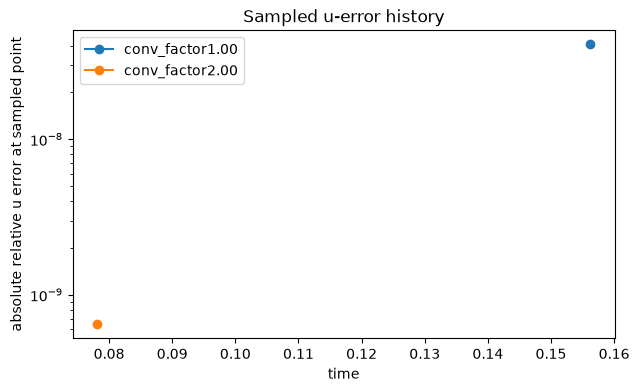

In [14]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for name, rows in sorted(diagnostic_rows.items()):
    positive_rows = [row for row in rows if abs(row[1]) > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [abs(row[1]) for row in positive_rows]
    label = name.replace("out0d-", "").replace(".txt", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("absolute relative u error at sampled point")
plt.title("Sampled u-error history")
plt.legend()
plt.show()

The runtime parameter file matches the displayed diagnostics. The two diagnostic
files show the same Cartesian wave project running at two resolutions after
generation and compilation, with the refined run producing smaller sampled
relative errors.

## Learning Check

After building, point to the file that contains run settings and the file that
contains the wave update formula. If you cannot, inspect the project inventory
again.

## Continue to Curvilinear Coordinates
- [Curvilinear Wave Equation](wave_equation_curvilinear.ipynb)
- [Reference-Metric Applications](../4-curvilinear/reference_metric_applications.ipynb)
- [BHaH Project Anatomy](../5-infrastructures/bhah_project_anatomy.ipynb)